### 多次元ガウス分布

２次元ガウス分布の当てはめ

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv('sensor_data/sensor_data_700.txt', delimiter=" ", header=None, names=("date", "time", "ir", "lidar"))
data

,date,time,ir,lidar
0,20180205,84535,16,734
1,20180205,84538,17,736
2,20180205,84541,6,733
3,20180205,84544,17,738
4,20180205,84547,16,734
...,...,...,...,...
86185,20180208,95056,30,746
86186,20180208,95059,20,739
86187,20180208,95102,9,744
86188,20180208,95104,18,741


In [2]:
# 12時から16時までのデータだけを抽出
d = data[(data['time'] < 160000) & (data['time'] >= 120000)]
d = d.loc[:, ['ir', 'lidar']]
d

,ir,lidar
3832,17,726
3833,14,730
3834,14,724
3835,21,724
3836,26,725
...,...,...
65155,8,729
65156,25,730
65157,10,731
65158,15,735


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'hu'
  cset = contour_func(


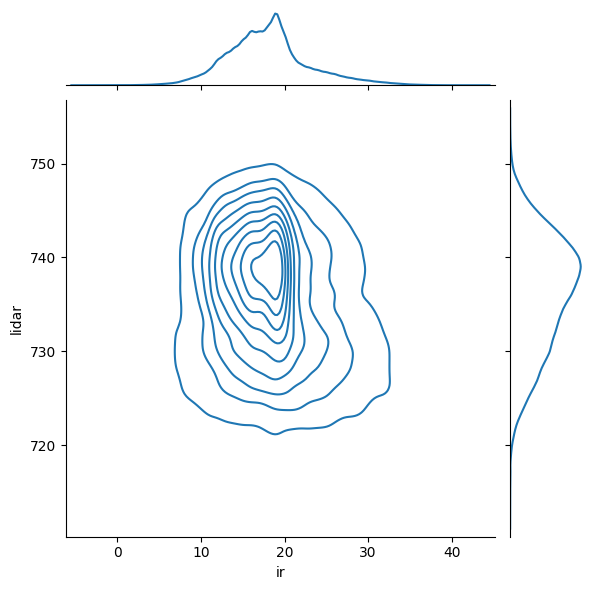

In [22]:
sns.jointplot(x=data['ir'], y=data['lidar'], hue=data, kind='kde') # 2次元のカーネル密度推定
plt.show()

分散・共分散・精度

In [4]:
print("光センサの計測値の分散", d.ir.var())
print("Lidarの計測値の分散", d.lidar.var())

# 平均からの距離
diff_ir = d.ir - d.ir.mean()
diff_lidar = d.lidar - d.lidar.mean()
print("diff_ir", diff_ir)
print("diff_lidar", diff_lidar)

光センサの計測値の分散 42.117126367701594
Lidarの計測値の分散 17.702026469211457
diff_ir 3832     -2.860247
3833     -5.860247
3834     -5.860247
3835      1.139753
3836      6.139753
           ...    
65155   -11.860247
65156     5.139753
65157    -9.860247
65158    -4.860247
65159    -0.860247
Name: ir, Length: 14175, dtype: float64
diff_lidar 3832    -3.311958
3833     0.688042
3834    -5.311958
3835    -5.311958
3836    -4.311958
           ...   
65155   -0.311958
65156    0.688042
65157    1.688042
65158    5.688042
65159    3.688042
Name: lidar, Length: 14175, dtype: float64


In [5]:
a = diff_ir * diff_lidar
print("共分散 ", sum(a) / (len(d)-1))

共分散  -0.31677803385437114


In [6]:
d.mean()

ir        19.860247
lidar    729.311958
dtype: float64

Pandasから一発で共分散を取得

In [7]:
d.cov() # 分散共分散行列

,ir,lidar
ir,42.117126,-0.316778
lidar,-0.316778,17.702026


平均と分散の推定値に基づく2次元ガウス分布

In [8]:
from scipy.stats import multivariate_normal

irlidar = multivariate_normal(mean=d.mean().values.T, cov=d.cov().values)

In [9]:
import numpy as np

x, y = np.mgrid[0:40, 710:750] # 2次元平面に均等にx,y座標点を打つ
pos = np.empty(x.shape + (2,)) # (40,40)次元に3次元目に(2,)を追加して(40,40,2)とする
pos

array([[[6.86205673e-310, 5.40717798e-315],
        [5.36615575e-315, 5.40036446e-315],
        [4.94065646e-324, 5.41786703e-315],
        ...,
        [5.41786707e-315, 5.41786945e-315],
        [0.00000000e+000, 1.82804289e-322],
        [1.87744945e-322, 1.92685602e-322]],

       [[0.00000000e+000, 1.97626258e-323],
        [6.36598737e-313, 0.00000000e+000],
        [5.41787016e-315, 0.00000000e+000],
        ...,
        [1.67982320e-322, 1.72922976e-322],
        [1.77863633e-322, 1.82804289e-322],
        [1.87744945e-322, 1.92685602e-322]],

       [[0.00000000e+000, 4.94065646e-324],
        [9.88131292e-324, 1.48219694e-323],
        [1.97626258e-323, 2.47032823e-323],
        ...,
        [1.67982320e-322, 1.72922976e-322],
        [1.77863633e-322, 1.82804289e-322],
        [1.87744945e-322, 1.92685602e-322]],

       ...,

       [[3.69561103e-321, 3.70055169e-321],
        [3.50786609e-321, 3.51280674e-321],
        [3.51774740e-321, 3.52268805e-321],
        ...,
     

In [14]:
# 加えた3次元目にx,yを代入
pos[:,:,0] = x
pos[:,:,1] = y


print('x', x)
print('x.shape', x.shape)
print('y', y)
print('y.shape', y.shape)

print('pos', pos)
print('pos.shape', pos.shape)

x [[ 0  0  0 ...  0  0  0]
 [ 1  1  1 ...  1  1  1]
 [ 2  2  2 ...  2  2  2]
 ...
 [37 37 37 ... 37 37 37]
 [38 38 38 ... 38 38 38]
 [39 39 39 ... 39 39 39]]
x.shape (40, 40)
y [[710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 ...
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]]
y.shape (40, 40)
pos [[[  0. 710.]
  [  0. 711.]
  [  0. 712.]
  ...
  [  0. 747.]
  [  0. 748.]
  [  0. 749.]]

 [[  1. 710.]
  [  1. 711.]
  [  1. 712.]
  ...
  [  1. 747.]
  [  1. 748.]
  [  1. 749.]]

 [[  2. 710.]
  [  2. 711.]
  [  2. 712.]
  ...
  [  2. 747.]
  [  2. 748.]
  [  2. 749.]]

 ...

 [[ 37. 710.]
  [ 37. 711.]
  [ 37. 712.]
  ...
  [ 37. 747.]
  [ 37. 748.]
  [ 37. 749.]]

 [[ 38. 710.]
  [ 38. 711.]
  [ 38. 712.]
  ...
  [ 38. 747.]
  [ 38. 748.]
  [ 38. 749.]]

 [[ 39. 710.]
  [ 39. 711.]
  [ 39. 712.]
  ...
  [ 39. 747.]
  [ 39. 748.]
  [ 39. 749.]]]
pos.shape (40, 40, 2)


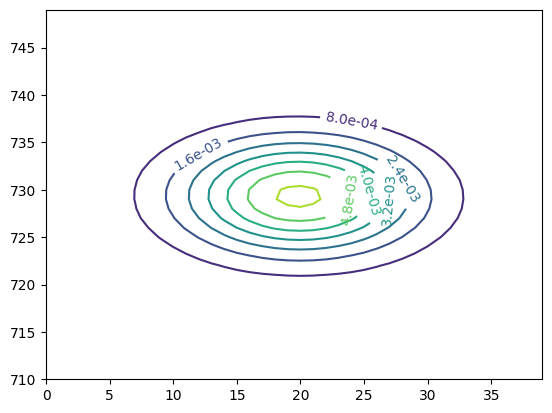

In [15]:
cont = plt.contour(x,y,irlidar.pdf(pos)) # x,y座標と各点に対応する確率密度を計算
cont.clabel(fmt='%1.1e')
plt.show()

In [19]:
print('x座標', x)
print('y座標', y)

x座標 [[ 0  0  0 ...  0  0  0]
 [ 1  1  1 ...  1  1  1]
 [ 2  2  2 ...  2  2  2]
 ...
 [37 37 37 ... 37 37 37]
 [38 38 38 ... 38 38 38]
 [39 39 39 ... 39 39 39]]
y座標 [[710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 ...
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]
 [710 711 712 ... 747 748 749]]


共分散の意味

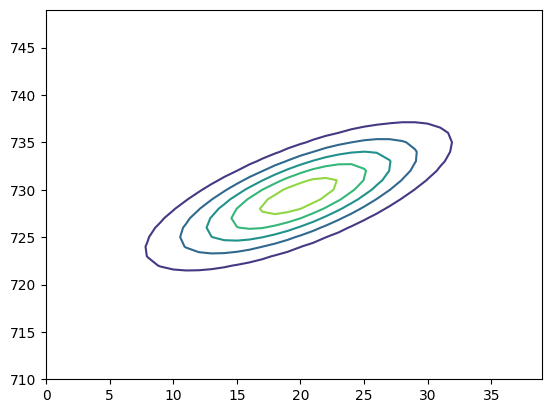

In [21]:
c = d.cov().values + np.array([[0,20],[20,0]])
tmp = multivariate_normal(mean=d.mean().values.T, cov=c)
cont = plt.contour(x,y,tmp.pdf(pos))
plt.show()

lidar 200mm に関するデータで2次元ヒストグラムを見てみる

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("sensor_data/sensor_data_200.txt", delimiter=" ",
                   header=None, names=("date", "time", "ir", "lidar"))

d = data.loc[:, ['ir', 'lidar']] # 光センサとLidarのみのデータ
d

,ir,lidar
0,305,214
1,299,211
2,292,199
3,321,208
4,298,212
...,...,...
58983,313,208
58984,297,200
58985,323,204
58986,326,207


,ir,lidar
ir,109.394583,-13.444661
lidar,-13.444661,23.408107


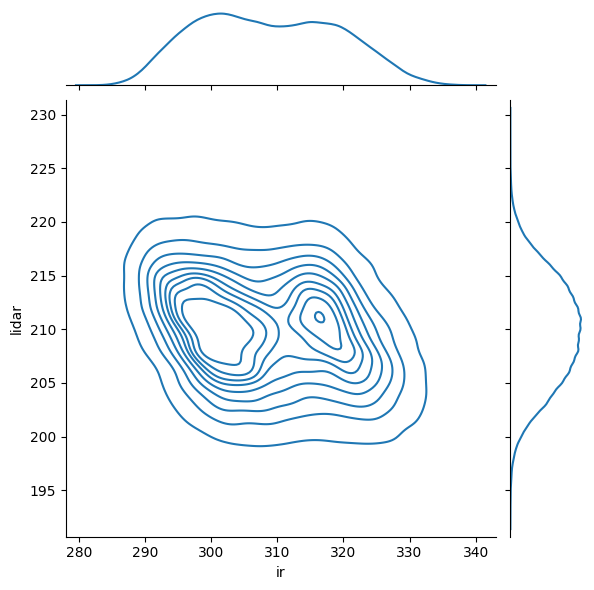

In [25]:
sns.jointplot(data=d, x=d['ir'], y=d['lidar'], kind='kde')
d.cov()

平均ベクトルと分散共分散ベクトルで2次元んガウス分布を推定

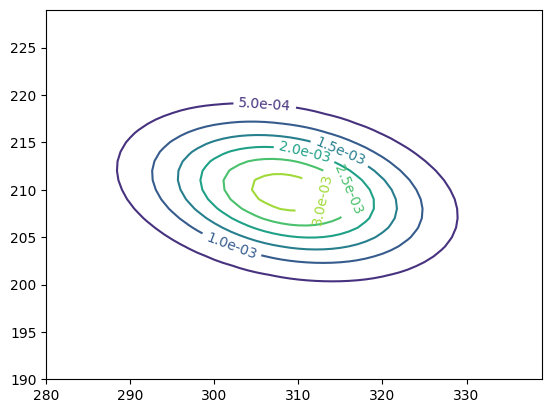

In [26]:
import numpy as np
from scipy.stats import multivariate_normal

x, y = np.mgrid[280:340, 190:230]
pos = np.empty(x.shape + (2,))
pos[...,0] = x
pos[...,1] = y

irlidar = multivariate_normal(mean=d.mean().values.T, cov=d.cov().values)
cont = plt.contour(x,y,irlidar.pdf(pos))
cont.clabel(fmt='%1.1e')
plt.show()

分散共分散行列と楕円誤差

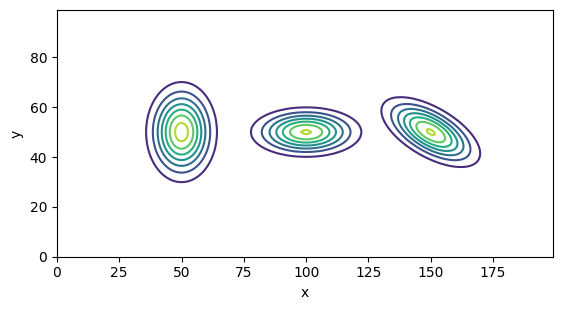

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
import math

x,y = np.mgrid[0:200, 0:100]
pos = np.empty(x.shape + (2,))
pos[...,0] = x
pos[...,1] = y

a = multivariate_normal(mean=[50,50], cov=[[50,0], [0, 100]])
b = multivariate_normal(mean=[100,50], cov=[[125,0],[0,25]])
c = multivariate_normal(mean=[150,50], cov=[[100,-25*math.sqrt(3)],[-25*math.sqrt(3),50]])

for e in [a,b,c]:
    plt.contour(x,y,e.pdf(pos))

plt.gca().set_aspect('equal')
plt.gca().set_xlabel('x')
plt.gca().set_ylabel('y')
plt.show()

分散共分散行列の固有値と固有ベクトル・・・ガウス分布の傾き

In [29]:
eig_vals, eig_vec = np.linalg.eig(c.cov)

print('eig_vals: ', eig_vals)
print('eig_vec: ', eig_vec)
print('固有ベクトル1: ', eig_vec[:, 0])
print('固有ベクトル2: ', eig_vec[:, 1])


eig_vals:  [125.  25.]
eig_vec:  [[ 0.8660254  0.5      ]
 [-0.5        0.8660254]]
固有ベクトル1:  [ 0.8660254 -0.5      ]
固有ベクトル2:  [0.5       0.8660254]


In [34]:
np.sqrt((eig_vec[:,0]**2).sum()) # 固有ベクトルの長さは1

1.0

+ 固有値 l1, l2
+ 固有ベクトル v1, v2
+ --- 上記に基づいて下記の2つのベクトルを図示する
+ ベクトル √l1 * v1, √l2 * v2 

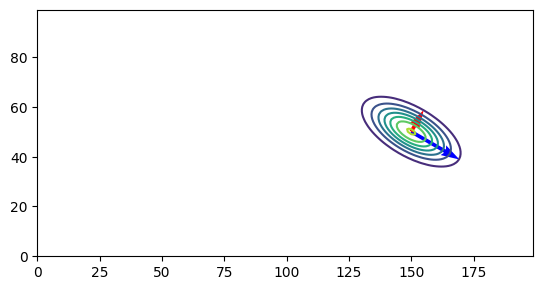

In [40]:
plt.contour(x,y,c.pdf(pos))

# Note: ベクトルが小さく表示されて見えないので故意に2倍の長さで表示

# 青色ベクトル
v1 = 2 * math.sqrt(eig_vals[0]) * eig_vec[:,0]
plt.quiver(c.mean[0], c.mean[1], v1[0], v1[1], color="blue", angles='xy', scale_units='xy', scale=1)

# 赤色ベクトル
v2 = 2 * math.sqrt(eig_vals[1]) * eig_vec[:,1] 
plt.quiver(c.mean[0], c.mean[1], v2[0], v2[1], color='red', angles='xy', scale_units='xy', scale=1)

plt.gca().set_aspect('equal')
plt.show()


対角化

+ Σ = VLV^(-1)
+ V = (v1, v2)
+ L = [[l1,0],[0,l2]]

対角化が成立しているかチェック

In [41]:
V = eig_vec # eig_vecには固有ベクトルが並んでいるのでそのまま使う
L = np.diag(eig_vals) # 対角行列を作成

print('分解したものを計算\n', V @ L @ np.linalg.inv(V))
print('元の分散共分散行列\n', np.array([[100,-25*math.sqrt(3)],[-25*math.sqrt(3),50]]))


分解したものを計算
 [[100.         -43.30127019]
 [-43.30127019  50.        ]]
元の分散共分散行列
 [[100.         -43.30127019]
 [-43.30127019  50.        ]]
